# 3.4 Milvus Ecosystem Features

In this section, we will explore some of the ecosystem tools around Milvus, look at Milvus' application prospects in more domains, and recommend resources for further learning.

## Overview of Milvus Ecosystem Tools

Milvus is not just a vector database; its ecosystem also includes a series of powerful tools and features to meet enterprise-level application needs.

### 1. [VTS (Vector Transport Service) for Data Synchronization](https://github.com/zilliztech/vts)

 **Description:**
 VTS (Vector Transport Service) is an open-source tool developed by Zilliz, focusing on the migration of vector and unstructured data. Based on Apache SeaTunnel, it is suitable for handling data migration from various sources (such as relational databases, data warehouses, S3) to Milvus.

 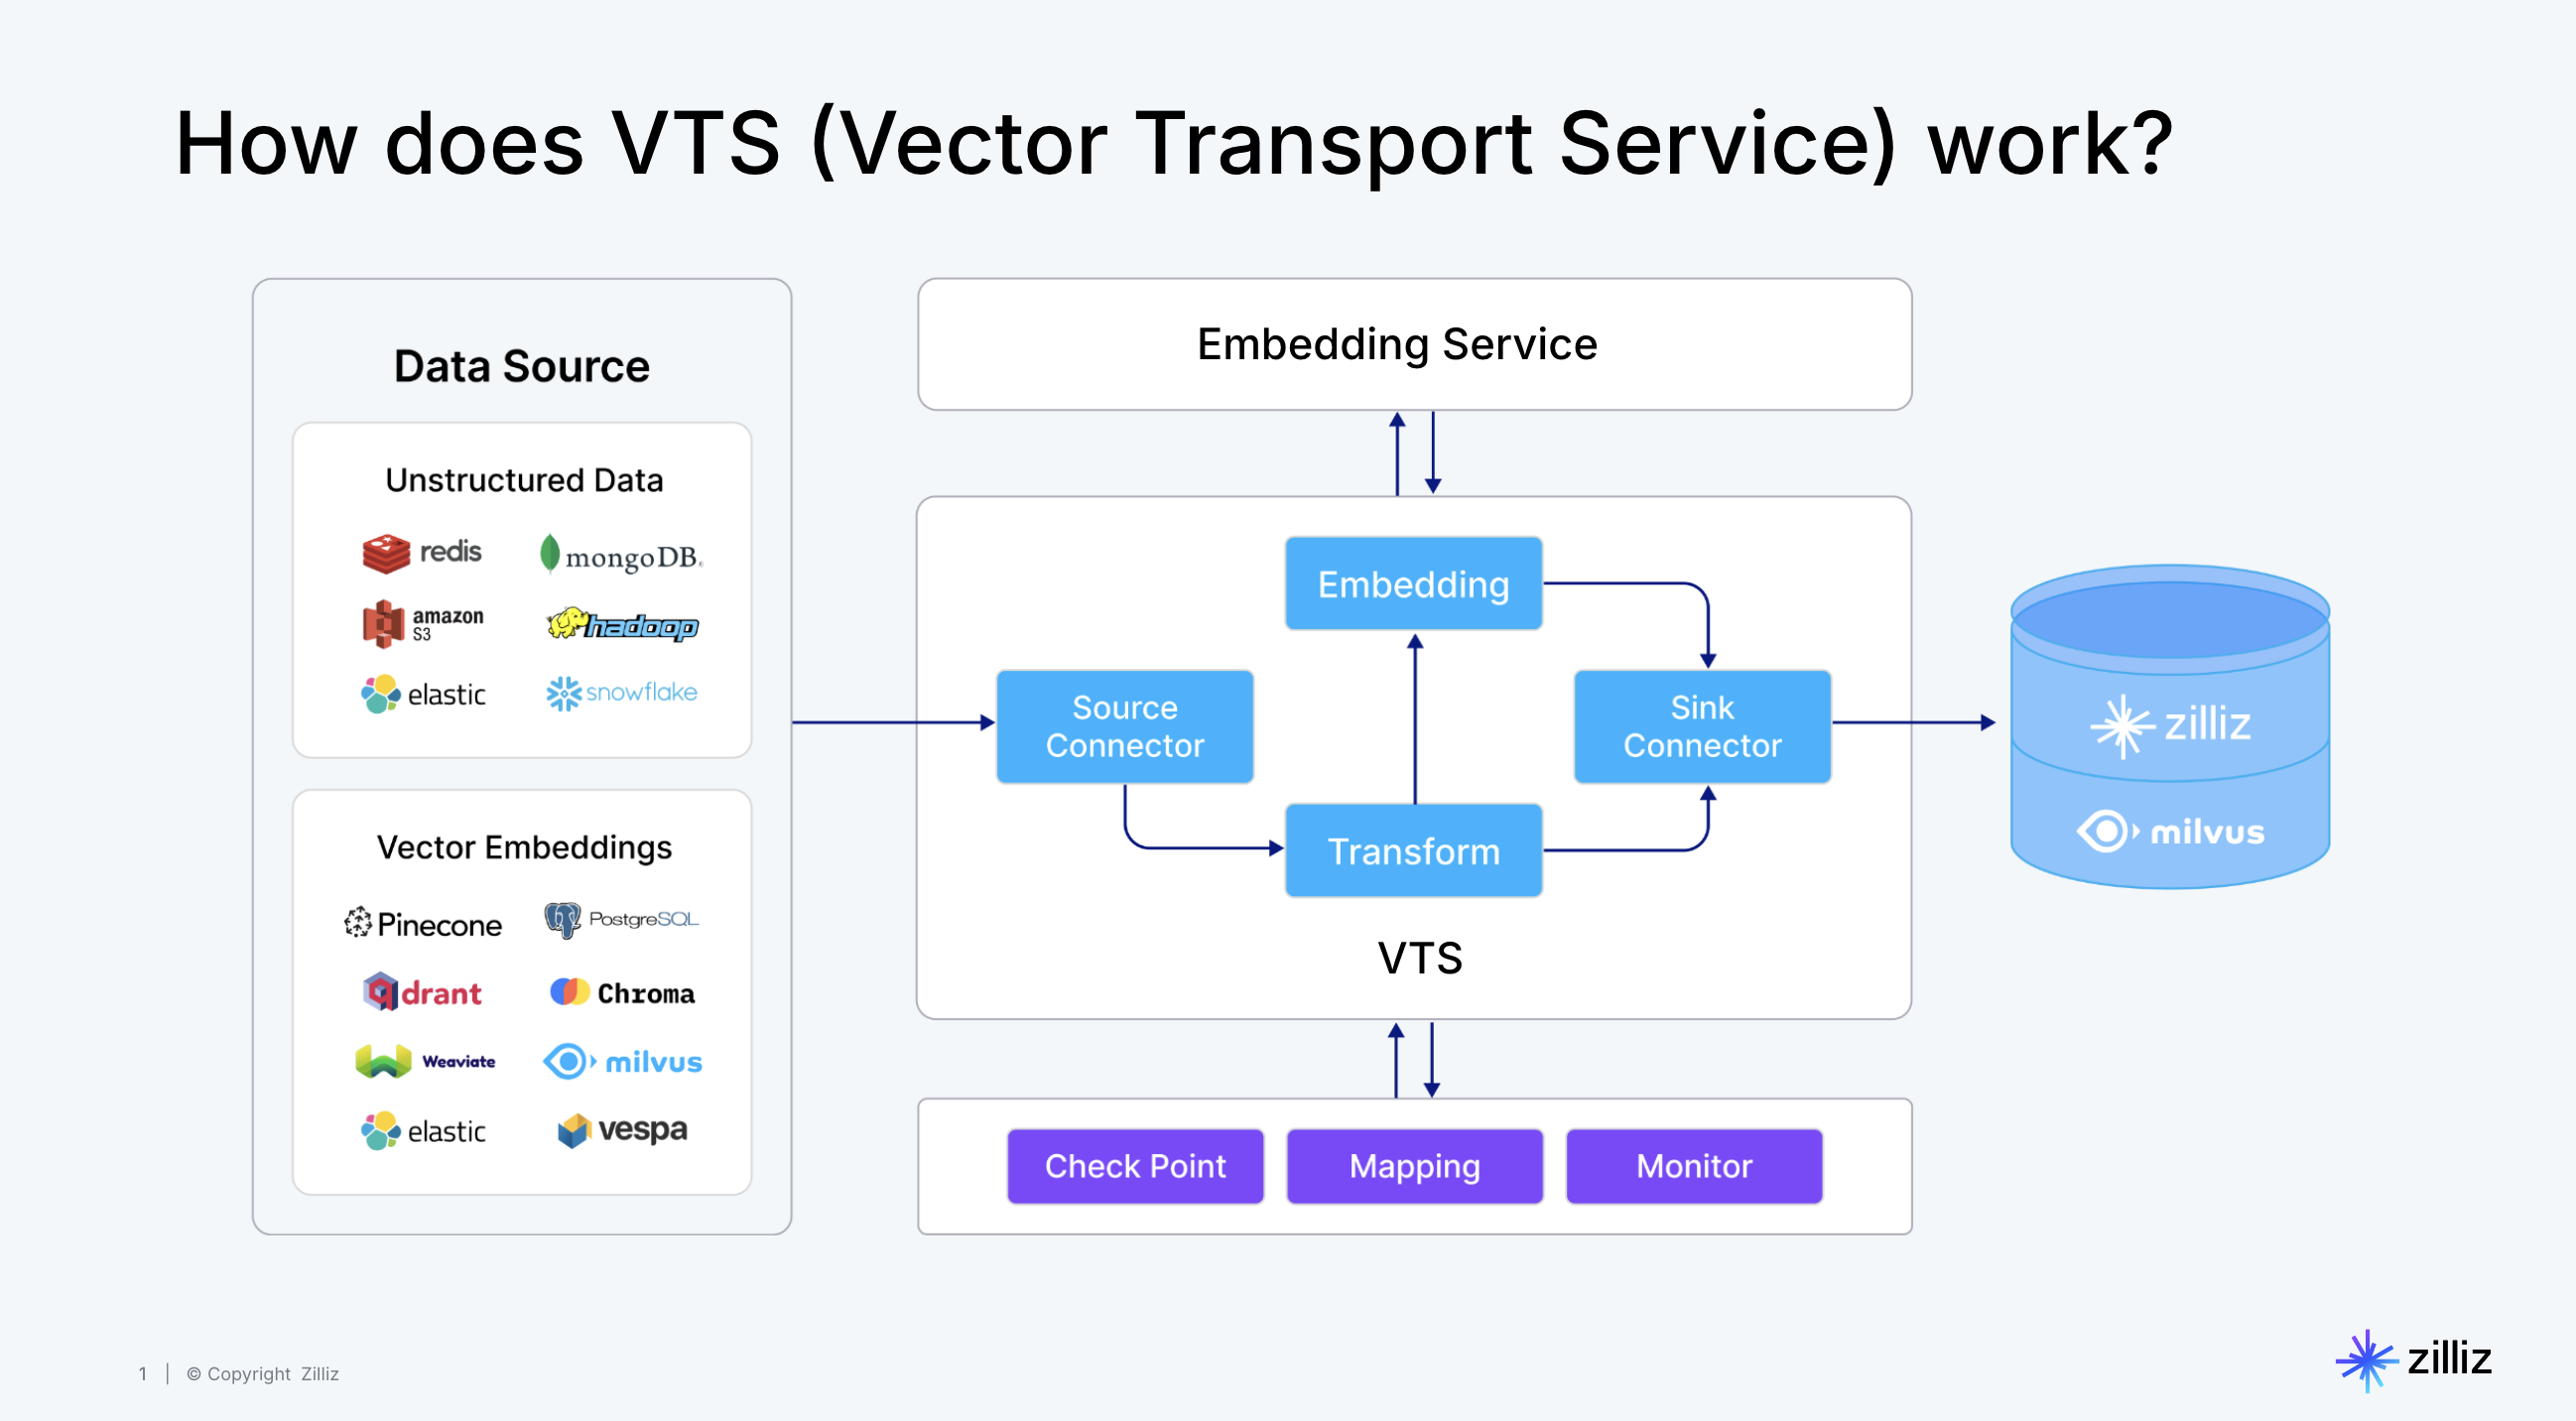

 **Main Use Cases:**

 | **Use Case**                          | **Description**                                                                 |
|-----------------------------------|-----------------------------------------------------------------------|
| Data Migration Requirements                      | Migrate from Milvus, Elasticsearch, etc. to Milvus with automatic schema conversion.              |
| Real-time and Offline Support                    | Provides real-time data streaming and offline batch import, flexibly adapting to different scenarios.                          |
| Unstructured Data Transformation                  | Supports vector embedding and tokenization through AI models, reducing data cleaning costs.                        |
| Data Quality Assurance                      | Provides monitoring and alerting mechanisms to prevent data loss and inconsistencies.                                |
| AI Application Data Pipeline                   | Optimizes scenarios such as image retrieval and recommendation systems, supporting real-time synchronization and loading.                        |
| Supported Data Sources                      | Milvus, Elasticsearch, Solr, PostgreSQL, Pinecone, Qdrant, etc.            |

 **Usage:**
 Typically a standalone command-line tool or configuration file-driven service. You need to specify source and target Milvus instances (or file paths), as well as the collections to migrate.

 **Example:**

- Install Docker, ensure Milvus version >= 2.3.6.
- Pull the image and run: `docker pull zilliz/vector-transport-service:latest`
- Configure migration file (e.g., migration.conf)
  ```
  env {
    parallelism = 1
    job.mode = "BATCH"
  }

  source {
    # Source configuration (e.g., Milvus, Elasticsearch, etc.)
    Milvus {
      url = "https://your-source-url:19530"
      token = "your-token"
      database = "default"
      collections = ["your-collection"]
      batch_size = 100
    }
  }
  
  sink {
    # Target configuration
    Milvus {
      url = "https://your-target-url:19530"
      token = "your-token"
      database = "default"
      batch_size = 10
    }
  }
  ```
- Then run the command like `./bin/seatunnel.sh --config ./migration.conf`

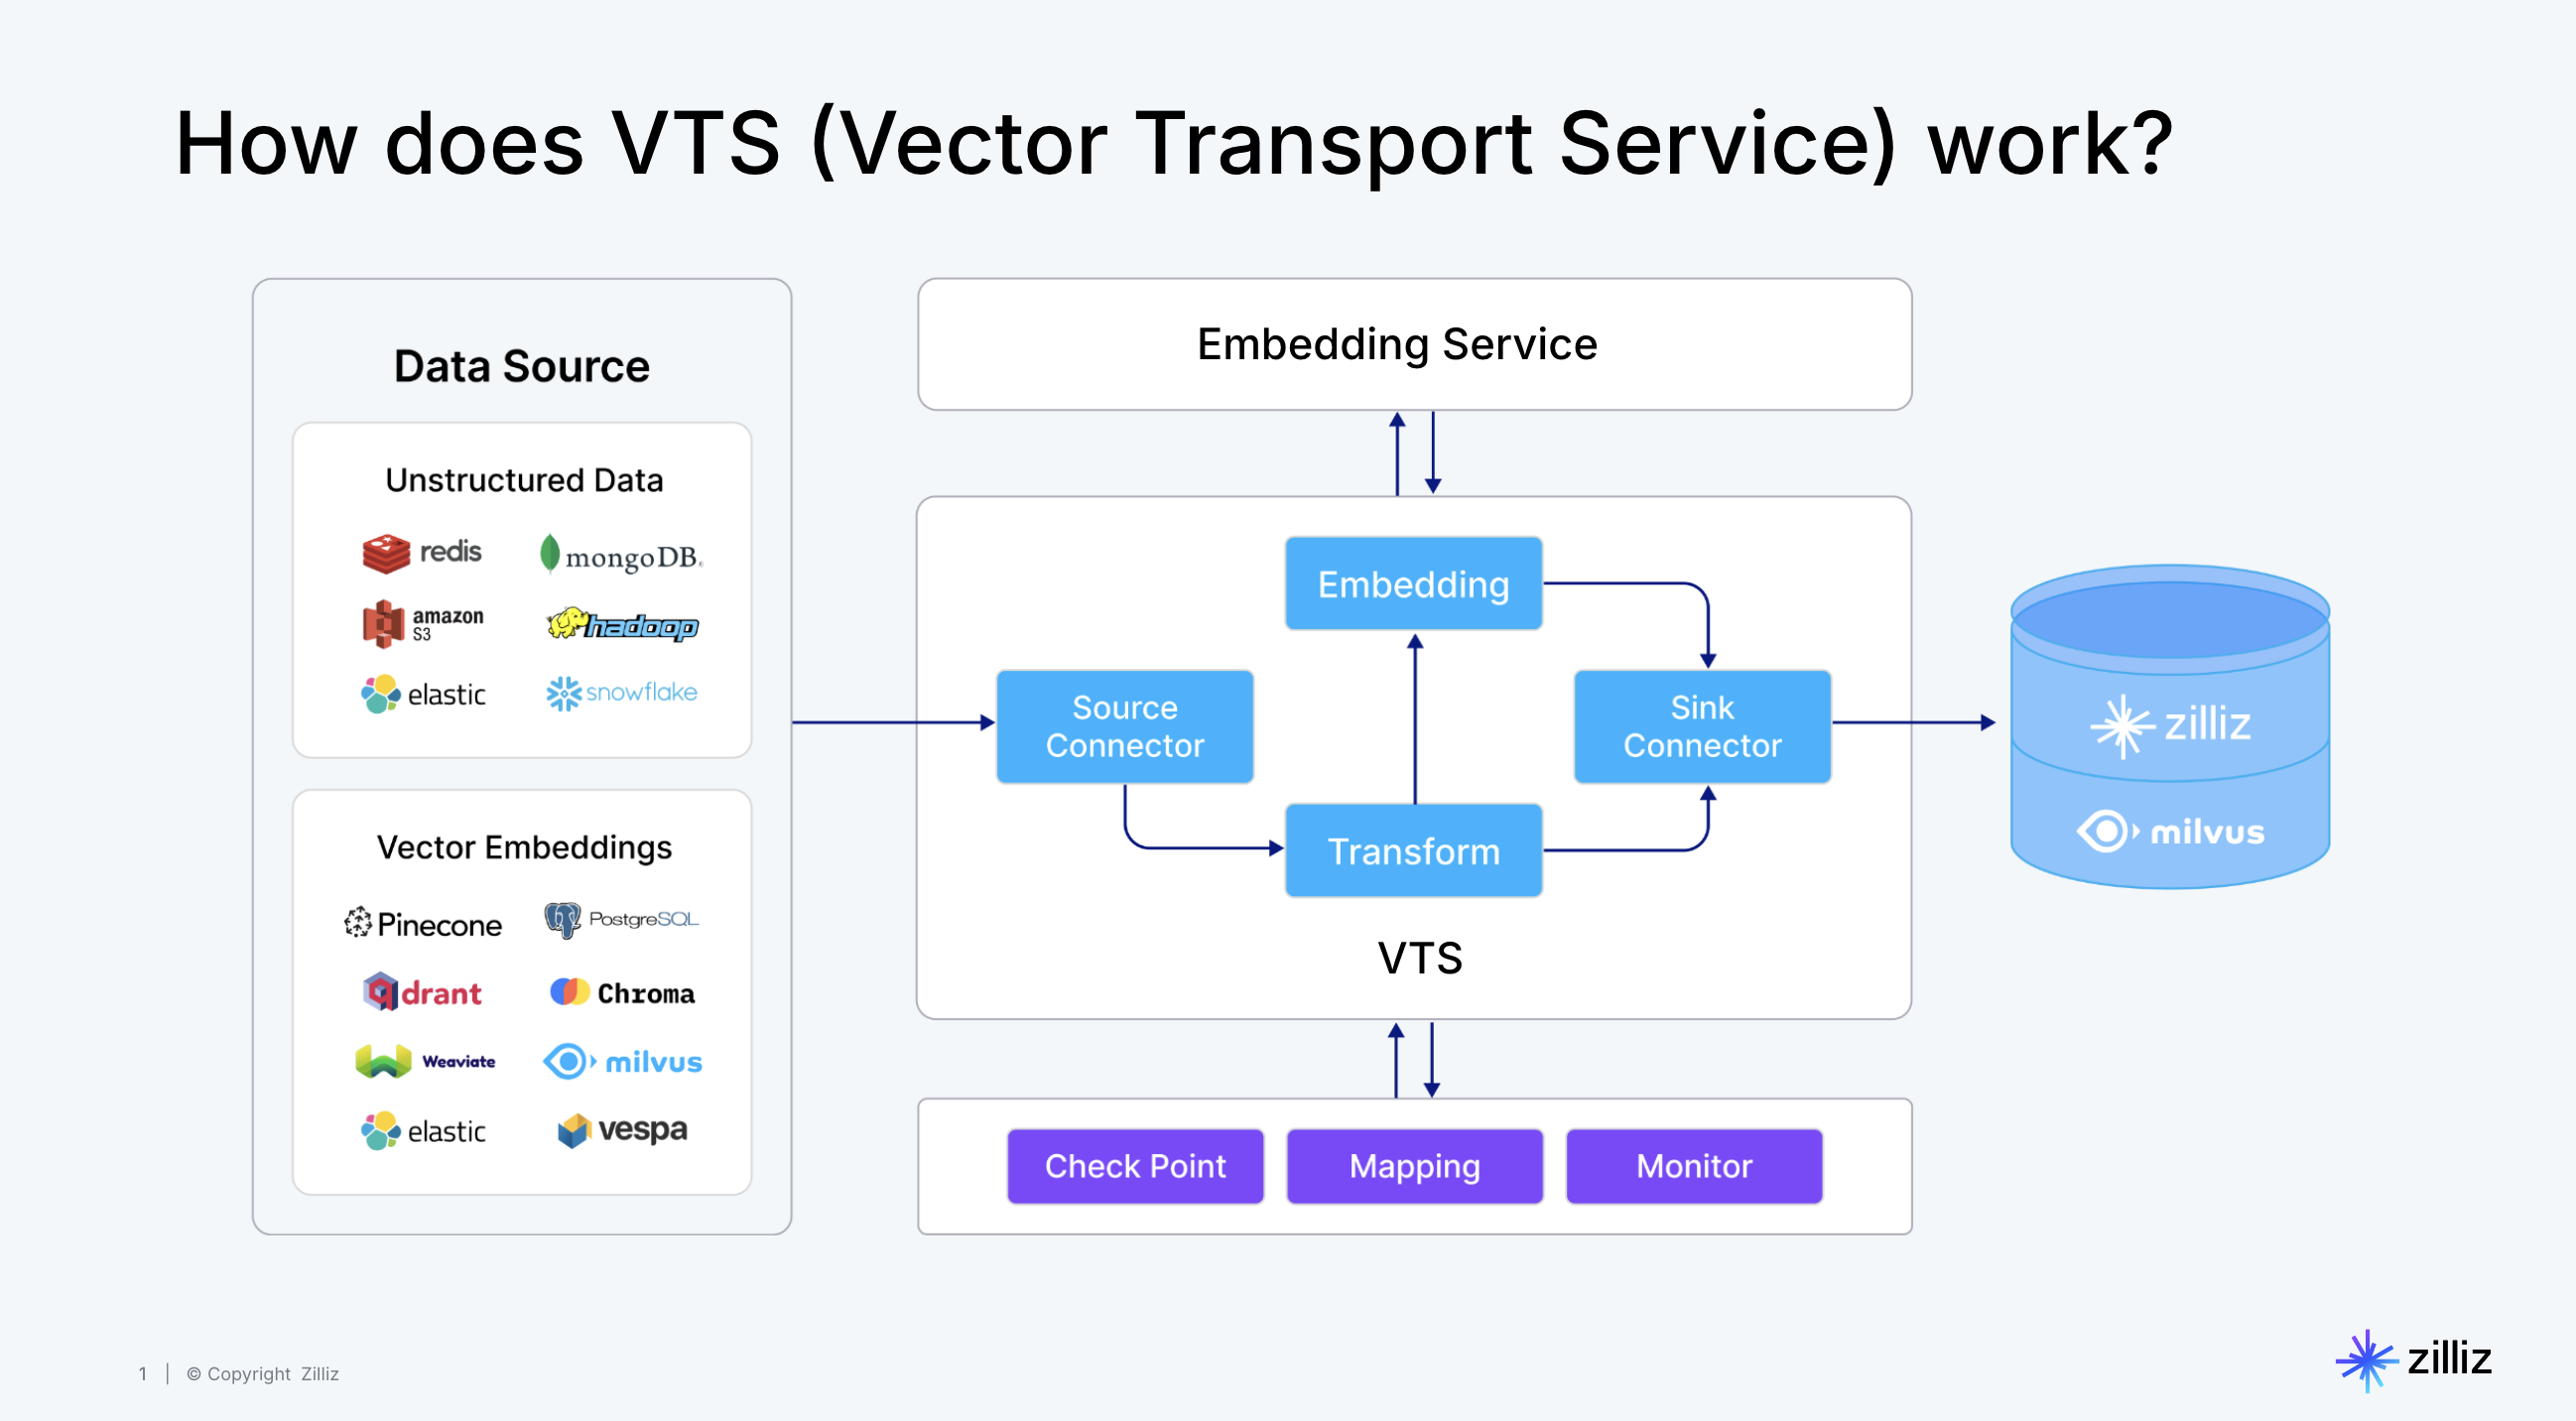

### 2. [Milvus CDC (Change Data Capture)](https://github.com/zilliztech/milvus-cdc)

 **Description:**
 Milvus-CDC is a user-friendly tool that can capture and synchronize incremental data changes in Milvus instances. It ensures the reliability of business data by seamlessly transferring data from the source instance to the target instance, supporting incremental backup and disaster recovery. Its workflow includes obtaining collection metadata from the source Milvus' etcd, connecting to a message queue (MQ) to subscribe to data streams, and processing data through the Go SDK or other means to replicate the operations of the source instance.

 **Main Use Cases:**
 *  **Improve Data Reliability**: By capturing and synchronizing incremental data, including insert and delete operations, reduces the possibility of data loss. This is particularly important for applications requiring continuous data consistency.  
 *  **Disaster Recovery**: Implements primary-backup switching functionality for Milvus, ensuring that even if the source cluster fails, the upper-layer services remain available. This is crucial for high-availability architectures.

 **Working Principle:**
 The CDC tool monitors Milvus data operation logs (or through specific APIs) and pushes change events to message queues (such as Kafka, Pulsar) or directly provides them to subscribers.

### 3. [Milvus Backup](https://github.com/zilliztech/milvus-backup)

 **Description:**
 Milvus Backup is an official command-line tool for backing up and restoring metadata and vector data of Milvus instances. It supports both full backups and incremental backups.

 **Main Advantages:**
 *   **Data Security:** Prevents data loss due to hardware failures, human errors, etc.
 *   **Disaster Recovery:** Enables rapid recovery of Milvus services in the event of a disaster.
 *   **Common Usage Scenarios:**
     - (1) Backup and restore within the same Milvus instance
       -  Same S3 (or MinIO) environment, same bucketName and rootPath.
       - After backing up a collection, restore to the same instance with a suffix (-s) or rename.
     - (2) Migration between different Milvus instances in one S3 storage service, same bucket
       - Two instances may have different rootPaths, such as files_A and files_B.
       - First create a backup in Milvus_A environment, then modify the configuration file in Milvus_B environment (pointing to the same bucket but different rootPath), execute restore.
     - (3) Migration between different buckets in one S3 storage service
       -  Milvus_A and Milvus_B use the same S3 address but different bucketNames, such as bucket_A and bucket_B.
       -  After creating a backup in instance A, the backup files will be written to backupBucketName/backupRootPath directory, then instance B restores with its own bucket.
     - (4) Across different S3 storage services
       -  Milvus_A and Milvus_B use minio_A and minio_B respectively.
       - After completing the backup in Milvus_A, manually migrate the backup files from minio_A to minio_B (e.g., using S3 copy tools), then execute restore in Milvus_B.

 **Usage (CLI Operations):**
 ```bash
 # Create backup 
 milvus-backup create -n my_backup_job \
                    -c my_collection1,my_collection2 \
                    --milvus-host <milvus_host> \
                    --milvus-port <milvus_port> \
                    --backup-path s3://my-bucket/milvus-backups/

 # Restore backup 
 milvus-backup restore -n my_backup_job \
                     -p s3://my-bucket/milvus-backups/my_backup_job_timestamp \
                     --milvus-host <target_milvus_host> \
                     --milvus-port <target_milvus_port>
 ```

**Comparison of the Above Tool Features**

* **Simplified Migration**: Use Vector Transport Service (VTS) to move data between platforms, whether migrating from Elastic/Pinecone/Qdrant or between Milvus deployments.
* **Reliable Backup**: Use the milvus-backup tool to create snapshots on persistent storage and restore them during data rollback or disaster recovery.
* **Data Replication**: Achieve higher availability in production environments. You can also implement hot-cold cluster setups through Milvus CDC.

### 4. [VectorDBBench](https://github.com/zilliztech/VectorDBBench)

 **Description:**
 VectorDBBench (VDBBench) is an open-source benchmarking tool sponsored by Zilliz, focusing on evaluating the performance and cost-effectiveness of vector databases, particularly suitable for vector database selection in artificial intelligence and machine learning applications.

 **Features**

 - **Benchmark Test Cases**: Includes 15 comprehensive test cases, divided into capacity testing, search performance testing, and filtered search performance testing, using public datasets such as SIFT, GIST, Cohere, and OpenAI-generated data, measuring the number of inserted vectors, index build time, recall, latency, and maximum QPS.
 - **Client Support**: Supports Milvus, Zilliz Cloud, Elastic Search, Pinecone, Qdrant Cloud, Weaviate Cloud, PgVector, Redis, Chroma, etc., with additional clients enabled through installation packages.
 - **Custom Dataset Testing**: Users can upload custom datasets in Parquet format for testing.
 - **Performance Leaderboard**: Provides an online leaderboard https://zilliz.com/benchmark, comparing systems based on metrics such as QPS, QP$, and latency.

 **Version 1.0**
 - 🚀 𝐑𝐞𝐝𝐞𝐬𝐢𝐠𝐧𝐞𝐝 𝐔𝐈: Brand new homepage design and integrated analysis page, making visualization and comparison of test results easier than ever.
 - 🏷️ 𝐋𝐚𝐛𝐞𝐥-𝐅𝐢𝐥𝐭𝐞𝐫 𝐓𝐞𝐬𝐭𝐬: Leverage new test cases with filter expressions (like "author = 'Shakespeare'") to simulate real query scenarios. The retrieval method combining metadata filtering with ANN search is gradually becoming a more mainstream solution than pure vector search.
 - 🌊 𝐒𝐭𝐫𝐞𝐚𝐦𝐢𝐧𝐠 𝐒𝐜𝐞𝐧𝐚𝐫𝐢𝐨𝐬: Conduct search performance testing while data is continuously being written to evaluate "write-while-read" retrieval capabilities.
 - 🔬 𝐍𝐞𝐰 𝐁𝐢𝐨𝐀𝐒𝐏 𝐃𝐚𝐭𝐚𝐬𝐞𝐭: Added 1024-dimensional vector dataset (containing 1 million and 10 million vectors) to meet performance testing needs for higher-dimensional vectors.
 - ⚙️ 𝐂𝐮𝐬𝐭𝐨𝐦 𝐃𝐚𝐭𝐚𝐬𝐞𝐭𝐬: Provides more flexible configuration options, allowing you to create datasets that fit your own data needs.

Current version requires `Python >= 3.11` and is installed via `pip install vectordb-bench`. Users can run it through the command line (e.g., `vectordbbench --help`) or interface (e.g., init_bench).

### 5. [Deep-searcher](https://github.com/zilliztech/deep-searcher)

 **Description:**
 
 DeepSearcher is an open-source project developed by Zilliz, aiming to provide an alternative for deep research and search on private data. The tool is built using Retrieval-Augmented Generation (RAG) technology, supporting features such as query routing, conditional execution workflows, and web crawling. It is a showcase case of agentic RAG. Through iterative refinement of queries, research, and analysis of information, it ultimately synthesizes reports, suitable for scenarios requiring deep research.
 
 Deep Research, as a landmark application of RAG advancing toward Agents, has become a hot topic of industry attention. These applications no longer follow simple preset retrieval-generation processes but can fully leverage the potential of large models to intelligently complete the entire research process from problem decomposition to multiple rounds of information retrieval to final report generation. [DEEP RESEARCH AGENTS: A SYSTEMATIC EXAMINATION AND ROADMAP](https://arxiv.org/abs/2506.18096)

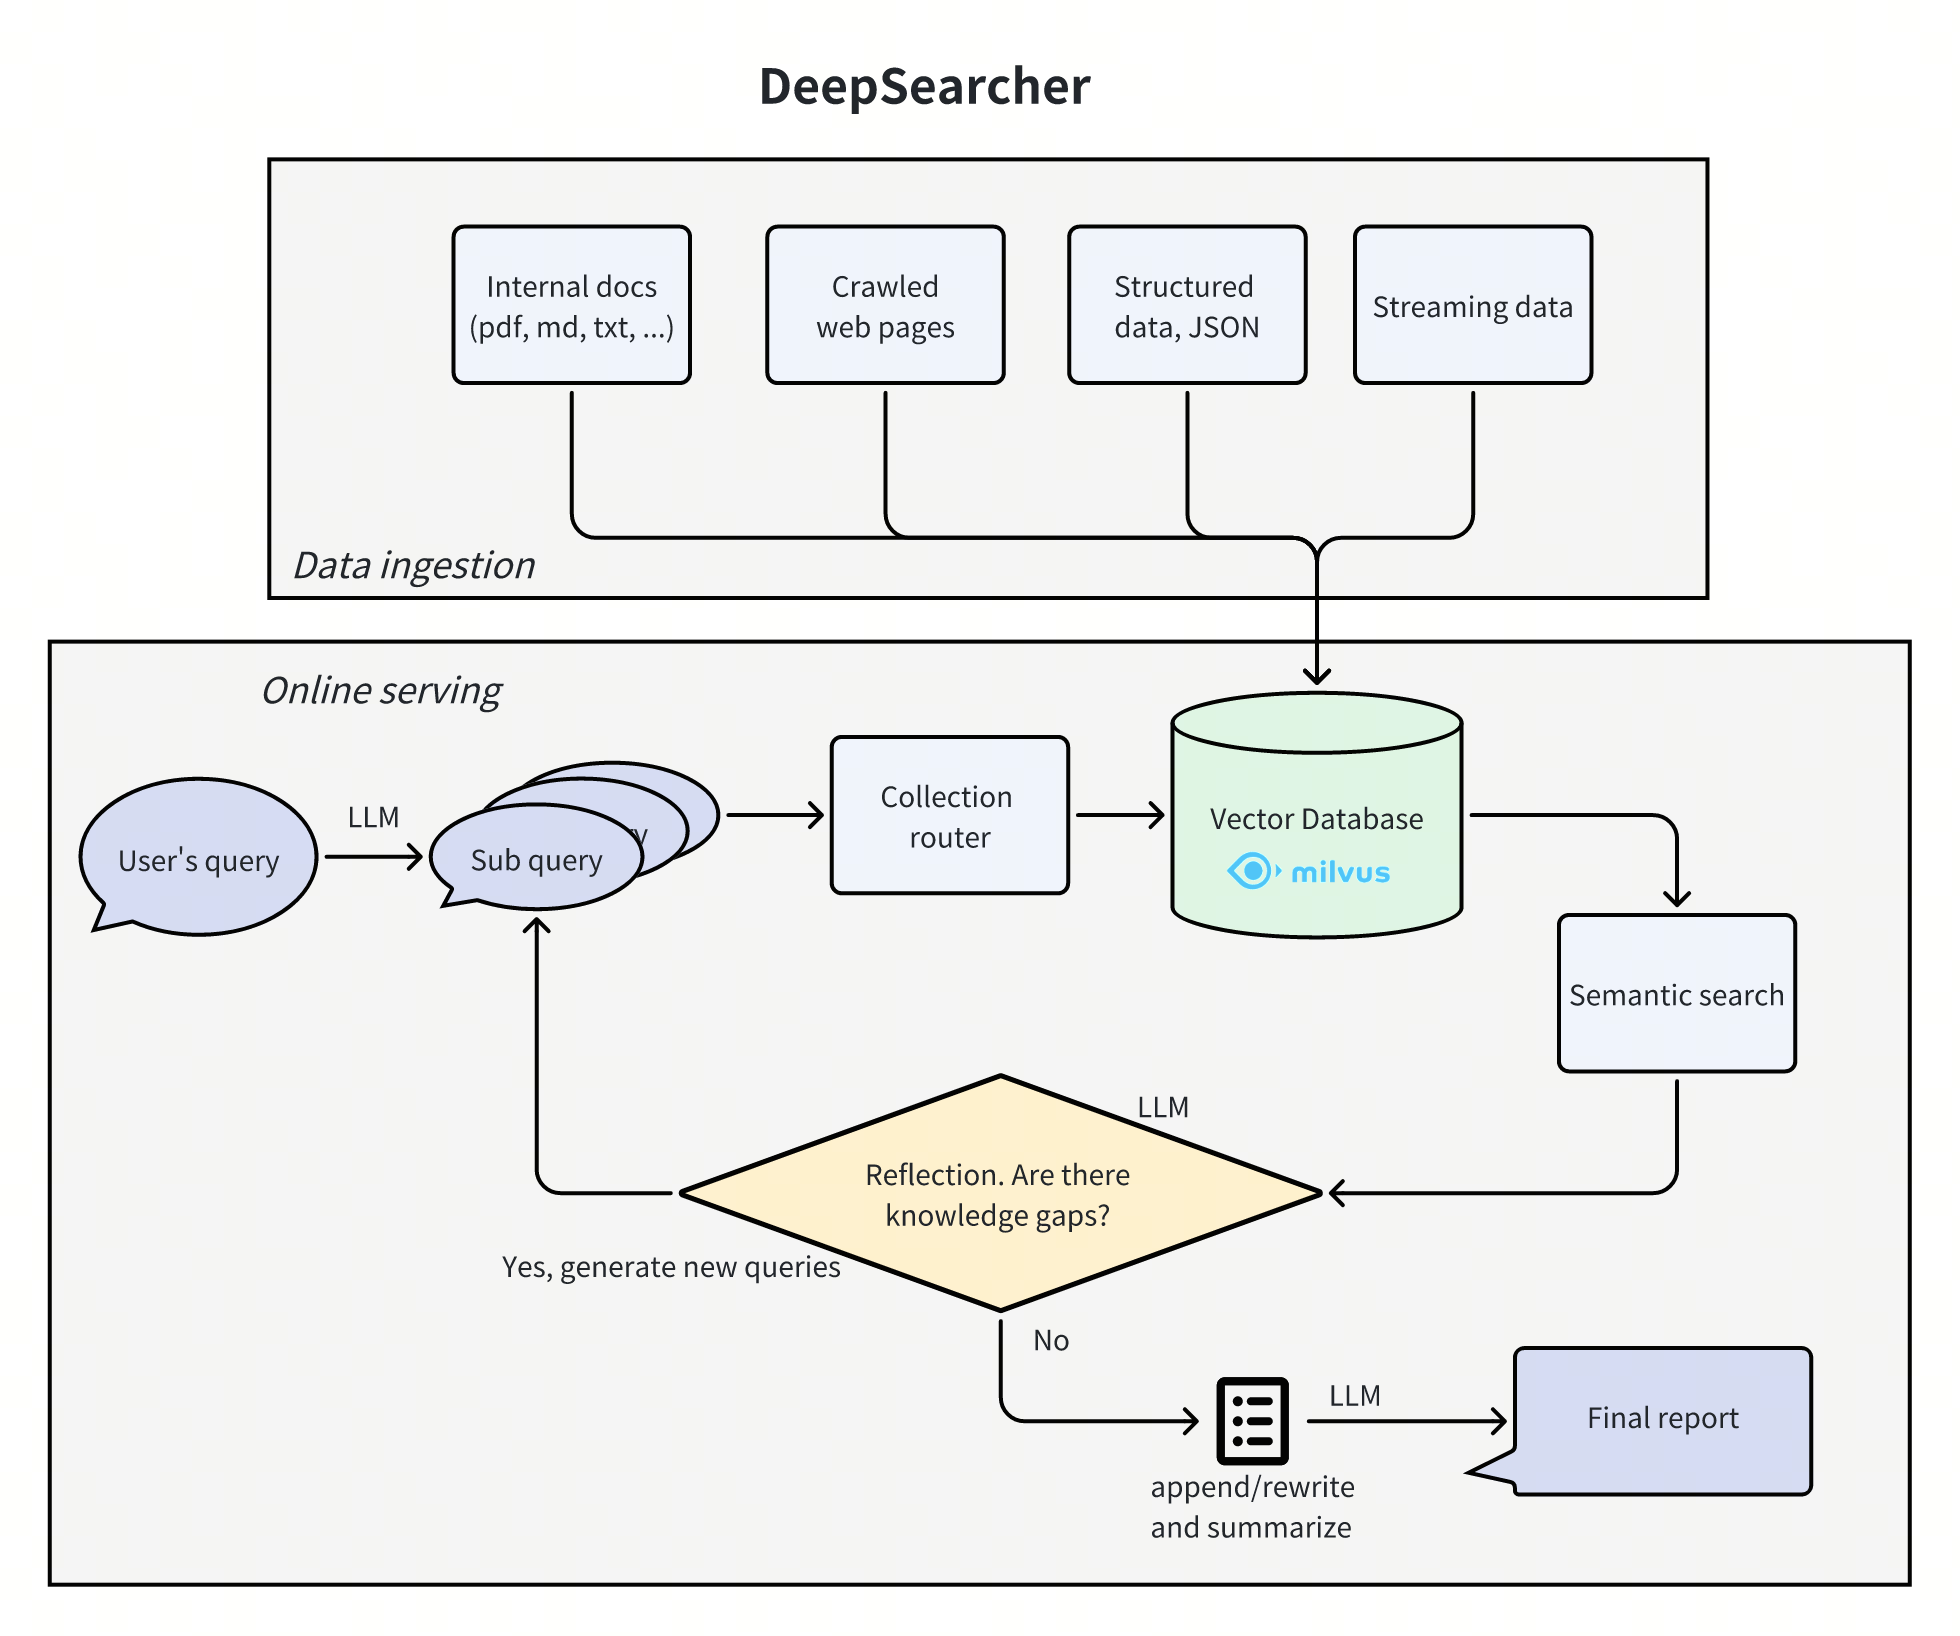

 **Features**
 *  **Automated Deep Research**: It can iteratively research a topic or question by browsing the web or internal documents, automating reasoning to decide the action for each step.  
 *  **Synthesis Report**: Integrates all research data into a coherent report, generated through a single prompt, suitable for scenarios requiring structured output.  
 *  **Enterprise Knowledge Management**: Helps enterprises manage and retrieve knowledge, especially suitable for handling internal documents.  
 *  **Intelligent Q&A System**: Through RAG technology, provides intelligent Q&A solutions, suitable for information retrieval and knowledge extraction.  
 *  **Information Retrieval Scenarios**: Suitable for various scenarios requiring deep search and analysis, such as academic research or business intelligence.

 **Example**

```python
from deepsearcher.configuration import Configuration, init_config
from deepsearcher.online_query import query

config = Configuration()

# Customize your config here,
# more configuration see the Configuration Details section below.
config.set_provider_config("llm", "OpenAI", {"model": "o1-mini"})
config.set_provider_config("embedding", "OpenAIEmbedding", {"model": "text-embedding-ada-002"})
init_config(config = config)

# Load your local data
from deepsearcher.offline_loading import load_from_local_files
load_from_local_files(paths_or_directory=your_local_path)

# (Optional) Load from web crawling (`FIRECRAWL_API_KEY` env variable required)
from deepsearcher.offline_loading import load_from_website
load_from_website(urls=website_url)

# Query
result = query("Write a report about xxx.") # Your question here
```




### 6. [MCP Server for Milvus](https://github.com/zilliztech/mcp-server-milvus)

 Demo: https://github.com/zilliztech/mcp-server-milvus/blob/main/Claude_mcp+1080.gif

 **How to Get Started Quickly with Zilliz MCP Server**
 - Step 1: Register or log in at https://zilliz.com/
 - Step 2: Install and run Zilliz MCP Server, link: https://github.com/zilliztech/zilliz-mcp-server
 - Step 3: Configure your AI assistant (such as Claude, Cursor, Windsurf, etc.). After setup is complete, you can create collections, insert vectors, and build semantic search through natural language, experiencing the next generation of conversational database development.

### 7. Other Milvus Application Scenarios

As a high-performance vector database, Milvus' application scenarios extend far beyond basic image or text similarity search. With the development of AI technology, vector embeddings are becoming a universal method for representing various complex data, and Milvus' application prospects are therefore becoming even broader.

 ### Recommendation Systems

 **Core Concept:**
 Represent both users and items as vector embeddings.
 *   **User Embedding:** Can be generated based on user's historical behavior (clicks, purchases, ratings), user profiles, etc.
 *   **Item Embedding:** Can be generated based on item content features (such as product descriptions, movie genres, music styles) or collaborative filtering models.

 **Milvus' Role:**
 1.  **Store User and Item Embeddings:** Create separate Collections in Milvus for users and items (or use partitions within the same Collection to distinguish them).
 2.  **Recall:**
     *   **User-CF (User-based Collaborative Filtering):** Given a user A, search in Milvus for other users with the most similar Embeddings, then recommend items that these similar users like.
     *   **Item-CF (Item-based Collaborative Filtering):** Given an item I that user A likes, search in Milvus for other items with Embeddings most similar to item I, and recommend them to user A.
     *   **Embedding-based Retrieval:** Given user A's Embedding, directly search in the Item Embeddings collection for the K most similar items to recommend.

**Example:** https://milvus.io/docs/movie_recommendation_with_milvus.md


 ### Anomaly Detection

 **Core Concept:**
 "Normal" data points will cluster together in vector space, while "anomalous" data points typically stay far from these clusters.

 **Milvus' Role:**
 1.  **Store Embeddings of Normal Data Points:**
     *   Use autoencoders, clustering algorithms (such as K-Means), or other unsupervised/semi-supervised methods to learn feature representations (Embeddings) from a large amount of "normal" data.
     *   Store the Embeddings of this "normal" data into Milvus.
 2.  **Detect Whether New Data Points are Anomalous:**
     *   For a new data point, first convert it to an Embedding of the same dimension.
     *   Search in Milvus for the K nearest neighbors of this Embedding.
     *   **Distance-based Anomaly Judgment:** If the average distance (or maximum distance, or distance to the Kth neighbor) between this Embedding and its nearest neighbors exceeds a preset threshold, the point is considered anomalous.
     *   **Density-based Anomaly Judgment:** If the number of points in the neighborhood of this Embedding is too small, it may also be considered anomalous.


To deepen your learning and mastery of Milvus, here are some valuable resources:

 ### 1. Official Documentation
 *   **Link:** [https://milvus.io/docs](https://milvus.io/docs)
 *   **Content:** The most authoritative and comprehensive source of information about Milvus. Includes installation guides, quick start, API reference, concept explanations, best practices, usage instructions for various tools, etc. Highly recommended to start here.

 ### 2. Milvus Community
 *   **Slack Channel:** [Milvus Slack](https://slack.milvus.io/)
     *   Directly communicate with Milvus developers and global users, ask questions, and share experiences.
 *   **GitHub Discussions:** [Milvus GitHub Discussions](https://github.com/milvus-io/milvus/discussions)
     *   A great place to ask questions, discuss features, and share ideas.
 *   **Zilliz Blog / Milvus Blog:**
     *   [Zilliz Blog](https://zilliz.com/blog) (Zilliz is the company behind Milvus)
     *   Typically publishes Milvus latest updates, technical articles, case studies, etc.
 *   **WeChat Official Account:** Search for "Zilliz" or "Milvus", there are officially operated accounts providing Chinese news and event information.

   ![image.png](attachment:62222708-a898-48c6-a28a-4aea8134a094.png)

 ### 3. GitHub Repositories
 *   **Milvus Main Repository:** [https://github.com/milvus-io/milvus](https://github.com/milvus-io/milvus)
     *   Milvus source code. You can submit issues, view source code, and contribute code.
 *   **Milvus Python SDK (PyMilvus):** [https://github.com/milvus-io/pymilvus](https://github.com/milvus-io/pymilvus)
     *   Source code and examples for the Python client.
 *   **Milvus Java SDK:** [https://github.com/milvus-io/milvus-sdk-java](https://github.com/milvus-io/milvus-sdk-java)
 *   **Milvus Go SDK:** [https://github.com/milvus-io/milvus-sdk-go](https://github.com/milvus-io/milvus-sdk-go)
 *   **Milvus Node.js SDK:** [https://github.com/milvus-io/milvus-sdk-node](https://github.com/milvus-io/milvus-sdk-node)
 *   **Milvus C# SDK:** [https://github.com/milvus-io/milvus-sdk-csharp](https://github.com/milvus-io/milvus-sdk-csharp)
 *   **Milvus Operator:** [https://github.com/zilliztech/milvus-operator](https://github.com/zilliztech/milvus-operator)
     *   Source code for the Kubernetes Operator.
 *   **Milvus Backup:** [https://github.com/zilliztech/milvus-backup](https://github.com/zilliztech/milvus-backup)
     *   Source code for the backup and restore tool.
 *   **Milvus Sizing Tool:** [https://github.com/zilliztech/milvus-sizing-tool](https://github.com/zilliztech/milvus-sizing-tool)
     *   Tool to help evaluate the resources required for Milvus deployment.
 *   **Milvus Examples / Bootcamp:**
     *   [https://github.com/milvus-io/bootcamp](https://github.com/milvus-io/bootcamp) (Highly recommended!)
     *   Contains a large number of directly runnable example code, covering various application scenarios, great material for hands-on practice.

 ### 4. Tutorials and Webinars
 *   **YouTube Channel:** Search for "Milvus" or "Zilliz". Official and community publish tutorial videos, webinar recordings, etc.
 *   **Participate in Online/Offline Meetups:** Follow Milvus community updates and participate in technical sharing events.